#  Анализ новостей Lenta.ru

В данном проекте мы проводим анализ новостного датасета Lenta.ru:
1. **Анализ данных**: Распределение тем и временной ряд.
2. **FastText**: Обучение классификатора и анализ векторных представлений.
3. **Классическое ML**: TF-IDF + Logistic Regression / Random Forest.


## 1.  Импорт библиотек


In [2]:
import pandas as pd
import io
import re
from nltk.corpus import stopwords
from pymorphy2 import MorphAnalyzer
import requests

import pickle
import tarfile
from tqdm import tqdm_notebook as tqdm

from multiprocessing import Pool


import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop = stopwords.words('russian')

from string import punctuation
punkt= [p for p in punctuation] + ["`", "``" ,"''", "'"]

    
import gensim

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import fasttext
import pymorphy2

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split


# !pip install MulticoreTSNE
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

## 2.  Загрузка и первичная обработка данных


In [3]:
# Загрузка данных
df = pd.read_csv("lenta-ru-news.csv",dtype = {3:str},low_memory = False)

In [3]:
df.head()

,url,title,text,topic,tags,date
0,https://lenta.ru/news/1914/09/16/hungarnn/,1914. Русские войска вступили в пределы Венгрии,Бои у Сопоцкина и Друскеник закончились отступ...,Библиотека,Первая мировая,1914/09/16
1,https://lenta.ru/news/1914/09/16/lermontov/,1914. Празднование столетия М.Ю. Лермонтова от...,"Министерство народного просвещения, в виду про...",Библиотека,Первая мировая,1914/09/16
2,https://lenta.ru/news/1914/09/17/nesteroff/,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в...",Библиотека,Первая мировая,1914/09/17
3,https://lenta.ru/news/1914/09/17/bulldogn/,1914. Бульдог-гонец под Льежем,Фотограф-корреспондент Daily Mirror рассказыва...,Библиотека,Первая мировая,1914/09/17
4,https://lenta.ru/news/1914/09/18/zver/,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передаю...",Библиотека,Первая мировая,1914/09/18


### Очистка и фильтрация тем
Оставляем только популярные темы (> 1000 записей).


In [4]:
df_nan = df[df['topic'].isna()] 
df_cleaned = df[df['topic'].notna()] 
print(df_cleaned["topic"].value_counts())  # Распределение по темам

Россия               160445
Мир                  136621
Экономика             79528
Спорт                 64413
Культура              53797
Бывший СССР           53402
Наука и техника       53136
Интернет и СМИ        44663
Из жизни              27605
Дом                   21734
Силовые структуры     19596
Ценности               7766
Бизнес                 7399
Путешествия            6408
69-я параллель         1268
Крым                    666
Культпросвет            340
Легпром                 114
Библиотека               65
Оружие                    3
ЧМ-2014                   2
МедНовости                1
Сочи                      1
Name: topic, dtype: int64


In [5]:
df_cleaned['topic_cleaned'] = df_cleaned['topic'].str.replace(' ', '_').str.lower()

C:\Users\User\AppData\Local\Temp\ipykernel_17088\3690088762.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['topic_cleaned'] = df_cleaned['topic'].str.replace(' ', '_').str.lower()


In [6]:
topics_to_use = df_cleaned.topic_cleaned.value_counts()[df_cleaned.topic_cleaned.value_counts() > 10000].index
topics_to_use

Index(['россия', 'мир', 'экономика', 'спорт', 'культура', 'бывший_ссср',
       'наука_и_техника', 'интернет_и_сми', 'из_жизни', 'дом',
       'силовые_структуры'],
      dtype='object')

In [7]:
data = df_cleaned[df_cleaned.topic_cleaned.isin(topics_to_use)]

## 3.  Разведочный анализ данных (EDA)
Посмотрим на распределение тем и дат.


In [8]:
data.topic_cleaned.value_counts(normalize=True)*100

россия               22.441743
мир                  19.109436
экономика            11.123731
спорт                 9.009567
культура              7.524687
бывший_ссср           7.469438
наука_и_техника       7.432232
интернет_и_сми        6.247098
из_жизни              3.861163
дом                   3.039975
силовые_структуры     2.740929
Name: topic_cleaned, dtype: float64

In [9]:
data.date = pd.to_datetime(data.date)

C:\Users\User\AppData\Local\Temp\ipykernel_17088\2044447706.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.date = pd.to_datetime(data.date)


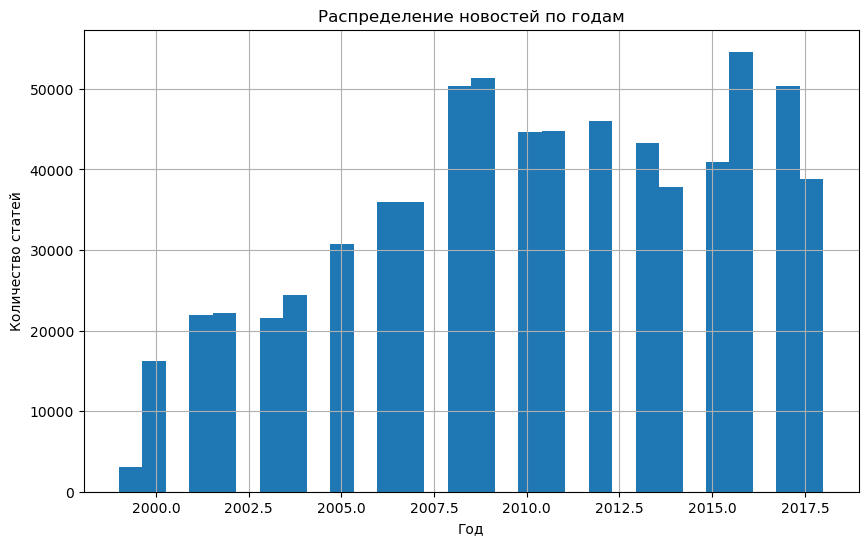

In [11]:
import matplotlib.pyplot as plt

# Построение гистограммы
ax = data.date.dt.year.hist(bins=30, figsize=(10, 6))

# Настройки графика
ax.set_title('Распределение новостей по годам')
ax.set_xlabel('Год')
ax.set_ylabel('Количество статей')

# Сохранение в файл
plt.savefig('news_by_year.png', dpi=300, bbox_inches='tight')
# plt.close()  # Закрываем график, чтобы не показывался в блокноте

## 4.  Предобработка текста
Токенизация и лемматизация заголовков.


In [12]:
lemmatizer = MorphAnalyzer()

In [13]:
def tokenize(sent):
    try:
        sent = word_tokenize(sent)
        return [word for word in sent if word not in stop and word not in punkt]
    
    except:
        return []
    
def lemmatize(sent):
    try:
        return " ".join([lemmatizer.normal_forms(word)[0] for word in sent])
    except:
        return " "

    
def preprocess_sent(sent):
    return lemmatize(tokenize(sent))

In [14]:
news_title = data['title']
news_text = data['text']
news_topic = data['topic_cleaned']
news_topic

5              россия
6              россия
7              россия
8                 мир
9              россия
             ...     
739171            мир
739172    бывший_ссср
739173            дом
739174          спорт
739175         россия
Name: topic_cleaned, Length: 714940, dtype: object

 **Запуск предобработки** (может занять время):


In [15]:
from tqdm import tqdm

titles_list = news_title.tolist()

titles_preprocessed = []
for title in tqdm(titles_list, total=len(titles_list)):
    processed_title = preprocess_sent(title)
    titles_preprocessed.append(processed_title)

  5%|███▍                                                                     | 33573/714940 [00:30<10:15, 1106.26it/s]


KeyboardInterrupt: 

## 5. FastText: Подготовка данных
Формируем train/test файлы для библиотеки FastText.


In [16]:
y = news_topic.tolist()

In [17]:
title_train, title_test, y_train, y_test = train_test_split(titles_preprocessed, y, test_size=0.25, stratify=y, random_state=33)

ValueError: Found input variables with inconsistent numbers of samples: [33573, 714940]

In [25]:
with open('train_data_titles.txt', 'w+', encoding='utf-8') as tr:
    for idx in range(len(title_train)):
        tr.write('__label__' + y_train[idx]+' '+title_train[idx]+'\n')
        
with open('test_data_titles.txt', 'w+', encoding='utf-8') as te:
    for idx in range(len(title_test)):
        te.write('__label__' + y_test[idx]+' '+title_test[idx]+'\n') 

###  Обучение FastText (Supervised)


In [26]:
%%time
ft_model = fasttext.train_supervised(input='train_data_titles.txt')

Wall time: 3.55 s


In [30]:
ft_model.test('test_data_titles.txt', k=1)

(178735, 0.7879094749209724, 0.7879094749209724)

###  Автоматический подбор гиперпараметров


In [34]:
%%time
ft_model_p_o = fasttext.train_supervised(input='train_data_titles.txt', autotuneValidationFile='test_data_titles.txt')

Wall time: 5min 8s


In [35]:
ft_model_p_o.test('test_data_titles.txt')

(178735, 0.7964304696897642, 0.7964304696897642)

In [36]:
print(f'Best learning rate: {ft_model_p_o.lr} \nBest epochs: {ft_model_p_o.epoch} \nBest_word_Ngrams: {ft_model_p_o.wordNgrams}')

Best learning rate: 0.04282828938735292 
Best epochs: 10 
Best_word_Ngrams: 3


###  Векторные представления (Unsupervised)
Обучаем векторы слов и визуализируем через TSNE.


In [58]:
# with open('titles_unsupervised.txt', 'w+', encoding='utf-8') as titles:
#     for idx in range(len(titles_preprocessed)):
#         titles.write(titles_preprocessed[idx]+'\n')

In [38]:
%%time
ft_vectors = fasttext.train_unsupervised('titles_unsupervised.txt', minn=3,maxn=5, dim=50)

Wall time: 37.7 s


In [42]:
top3k_vectors = [ft_vectors.get_word_vector(word) for word in top3k]

In [43]:
%%time
tsne_emb = TSNE(n_components=2, n_iter=2000, n_jobs=-1).fit_transform(np.array(top3k_vectors))

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Wall time: 7.32 s


In [45]:
from bokeh.models import ColumnDataSource, LabelSet
from bokeh.plotting import figure, show, output_file
from bokeh.io import output_notebook

output_notebook()


p = figure(tools="pan,wheel_zoom,reset,save", title="TSNE representation of FastText vectors (top 1.5k words)")

source = ColumnDataSource(data=dict(x1=tsne_emb[:,0], x2=tsne_emb[:,1], names=top3k))

p.scatter(x="x1", y="x2", source=source, size=5)

words = LabelSet(x="x1", y="x2", text="names", source=source,
                y_offset=6, text_font_size="6pt",text_color="#555555", text_align="center")

p.add_layout(words)

show(p)


Loading BokehJS ...

## 6.  Классические модели (TF-IDF)
Сравним результат с Logistic Regression и Random Forest.


### 6.1 Векторизация (TF-IDF)


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    data['title'], 
    data['topic_cleaned'], 
    test_size=0.25, 
    random_state=42,
    stratify=data['topic_cleaned']  # сохраняем распределение тем
)

In [24]:
tfidf = TfidfVectorizer(
    max_features=5000,      #
    stop_words=stop, 
    ngram_range=(1, 2),     
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

### 6.2 Logistic Regression


In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000, multi_class='multinomial')
lr.fit(X_train_tfidf, y_train)

print(classification_report(y_test, lr.predict(X_test_tfidf)))

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


                   precision    recall  f1-score   support

      бывший_ссср       0.75      0.66      0.70     13351
              дом       0.73      0.56      0.64      5434
         из_жизни       0.46      0.26      0.34      6901
   интернет_и_сми       0.68      0.51      0.58     11166
         культура       0.66      0.61      0.63     13449
              мир       0.66      0.73      0.69     34155
  наука_и_техника       0.63      0.62      0.62     13284
           россия       0.59      0.75      0.66     40111
силовые_структуры       0.51      0.17      0.25      4899
            спорт       0.89      0.84      0.86     16103
        экономика       0.71      0.71      0.71     19882

         accuracy                           0.67    178735
        macro avg       0.66      0.58      0.61    178735
     weighted avg       0.67      0.67      0.66    178735



### 6.3 Random Forest


In [22]:
from sklearn.metrics import classification_report

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=20,max_depth=30)
rf.fit(X_train_tfidf, y_train)

print(classification_report(y_test, rf.predict(X_test_tfidf)))

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                   precision    recall  f1-score   support

      бывший_ссср       0.73      0.23      0.35     13351
              дом       0.89      0.08      0.15      5434
         из_жизни       0.50      0.00      0.00      6901
   интернет_и_сми       0.73      0.06      0.11     11166
         культура       0.88      0.08      0.15     13449
              мир       0.63      0.28      0.39     34155
  наука_и_техника       0.76      0.06      0.11     13284
           россия       0.27      0.94      0.42     40111
силовые_структуры       0.00      0.00      0.00      4899
            спорт       0.93      0.49      0.64     16103
        экономика       0.75      0.24      0.36     19882

         accuracy                           0.37    178735
        macro avg       0.64      0.22      0.24    178735
     weighted avg       0.62      0.37      0.32    178735



C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##  Заключение
Мы сравнили работу специализированной библиотеки FastText и классических подходов. FastText обеспечивает высокую скорость работы и хорошее качество на задачах классификации коротких текстов (заголовков).
